# **MVP — Controle Estatístico de Processo**
## **Previsão de Produtividade em Linha de Confecção de Vestuário**

**Universidade de Brasília — Departamento de Engenharia de Produção**

**Disciplina:** ERP - Controle Estatístico de Processos  

**Aluno:** Rodrigo Alonso Santos de Sousa

**Matrícula:** 221029365

**Professor:** Dr. André Luiz Marques Serrano



## **Definição do Problema**

### **Contexto**

A indústria de confecção de vestuário é intensiva em mão de obra e altamente sensível a variações de desempenho no chão de fábrica. A produtividade real de uma equipe depende de uma combinação de fatores: metas estabelecidas, incentivos financeiros, horas extras, **complexidade das operações (medida pelo *Standard Minute Value* — SMV)** e tamanho das equipes, entre outros.

Este projeto utiliza o dataset **Garment Worker Productivity** disponível no [Productivity Prediction of Garment Employees](https://www.kaggle.com/datasets/ishadss/productivity-prediction-of-garment-employees), que registra dados de produção de linhas de costura e acabamento de uma fábrica de confecção de Bangladesh ao longo de 3 meses **(janeiro a março de 2015)**.

### **Objetivo**

Construir um modelo preditivo supervisionado de **classificação binária** capaz de determinar se uma equipe de produção irá **atingir ou superar sua meta de produtividade** **(`actual_productivity >= targeted_productivity`)**. A variável-alvo criada é denominada **`atingiu_meta`**.

### **Hipóteses e Premissas**

- **H1:** Equipes com maior incentivo financeiro tendem a atingir a meta com mais frequência.
- **H2:** Operações com SMV mais alto **(mais complexas)** reduzem a probabilidade de atingir a meta.
- **H3:** Horas extras excessivas podem prejudicar a produtividade ao longo do tempo.
- **H4:** O departamento de `sweing` (costura) apresenta padrão de desempenho diferente do departamento de `finishing` (acabamento), dada a maior complexidade operacional.

### **Descrição do Dataset**

O dataset possui **1.197 registros** e **15 variáveis**:

| Variável | Tipo | Descrição |
|---|---|---|
| `date` | Categórica (data) | Data do registro |
| `quarter` | Categórica | Quinzena do mês (Quarter1 a Quarter5) |
| `department` | Categórica | Setor de produção (`sweing` ou `finishing`) |
| `day` | Categórica | Dia da semana |
| `team` | Numérica | Identificador da equipe (1 a 12) |
| `targeted_productivity` | Numérica | Meta de produtividade definida pela gestão |
| `smv` | Numérica | Standard Minute Value — tempo padrão da operação |
| `wip` | Numérica | Work in Progress — peças em processo |
| `over_time` | Numérica | Minutos de hora extra no dia |
| `incentive` | Numérica | Incentivo financeiro (BDT — taka bangladeshiano) |
| `idle_time` | Numérica | Tempo ocioso em minutos |
| `idle_men` | Numérica | Número de trabalhadores ociosos |
| `no_of_style_change` | Numérica | Número de mudanças de estilo/modelo no dia |
| `no_of_workers` | Numérica | Número de trabalhadores na equipe |
| `actual_productivity` | Numérica | **Variável base para o target** — produtividade real alcançada |

**Restrições de seleção:** Foram removidos registros com **`wip`** ausente apenas no pré-processamento específico para a carta de controle; para o modelo, a mediana será imputada. O campo **`department`** continha um espaço em branco em entradas do tipo **`finishing ` (com espaço)**, tratado na limpeza.

## **1. Preparação e Tratamento de Dados**

In [ ]:
# ============================================================
#  INSTALAÇÕES (rode apenas uma vez no Colab)
# ============================================================
!pip install imbalanced-learn xgboost --quiet

In [ ]:
# ============================================================
#  BIBLIOTECAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [ ]:
# ============================================================
#  CARGA DOS DADOS
# ============================================================
# O dataset está disponível publicamente no UCI / Kaggle.
# Faça o upload do arquivo garments_worker_productivity.csv
# via Colab (ícone de pasta à esquerda > Upload) ou use a linha abaixo.

# Opção 1 — upload manual (após subir o arquivo no Colab):
df_raw = pd.read_csv('garments_worker_productivity.csv')

# Opção 2 — leitura direta se o arquivo estiver no Drive montado:
# from google.colab import drive
# drive.mount('/content/drive')
# df_raw = pd.read_csv('/content/drive/MyDrive/garments_worker_productivity.csv')

print(f"Dataset carregado: {df_raw.shape[0]} linhas × {df_raw.shape[1]} colunas")
df_raw.head()

Dataset carregado: 1197 linhas × 15 colunas


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


### **1.1 Limpeza e Engenharia de Atributos**

In [ ]:
# ============================================================
#  LIMPEZA INICIAL
# ============================================================
df = df_raw.copy()

# Corrige espaço extra em 'finishing ' → 'finishing'
df['department'] = df['department'].str.strip()

# Converte data para datetime (não será usada como feature, mas auxilia análises)
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

print("Valores nulos por coluna:")
print(df.isnull().sum())
print(f"\nDepartamentos únicos: {df['department'].unique()}")

Valores nulos por coluna:
date                     562
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

Departamentos únicos: ['sweing' 'finishing']


In [ ]:
# ============================================================
#  CRIAÇÃO DA VARIÁVEL-ALVO
# ============================================================
# Definição: uma equipe 'atingiu_meta' se sua produtividade real
# for maior ou igual à meta estabelecida pela gestão.
df['atingiu_meta'] = (df['actual_productivity'] >= df['targeted_productivity']).astype(int)

print("Distribuição da variável-alvo:")
print(df['atingiu_meta'].value_counts())
print(f"\nProporção (%):\n{df['atingiu_meta'].value_counts(normalize=True)*100}")

Distribuição da variável-alvo:
atingiu_meta
1    875
0    322
Name: count, dtype: int64

Proporção (%):
atingiu_meta
1    73.099415
0    26.900585
Name: proportion, dtype: float64


In [ ]:
# ============================================================
#  ENGENHARIA DE ATRIBUTOS
# ============================================================
# Produtividade por trabalhador — normaliza o esforço pelo tamanho da equipe
df['overtime_per_worker'] = df['over_time'] / (df['no_of_workers'] + 1)

# Razão entre incentivo e tamanho da equipe
df['incentive_per_worker'] = df['incentive'] / (df['no_of_workers'] + 1)

# Gap entre meta e produtividade real (variável auxiliar — NÃO entra no modelo,
# pois usa actual_productivity que dá origem ao target)
# Mantida apenas para análise exploratória
df['gap_produtividade'] = df['actual_productivity'] - df['targeted_productivity']

print("Novas features criadas:")
print(df[['overtime_per_worker', 'incentive_per_worker', 'gap_produtividade']].describe())

Novas features criadas:
       overtime_per_worker  incentive_per_worker  gap_produtividade
count          1197.000000           1197.000000        1197.000000
mean            139.501562              1.590006           0.005459
std              78.027872             12.607943           0.160082
min               0.000000              0.000000          -0.561958
25%             107.256637              0.000000          -0.009556
50%             117.931034              0.000000           0.000505
75%             166.153846              0.900901           0.099111
max             600.000000            225.000000           0.644375


### **1.2 Análise Exploratória**

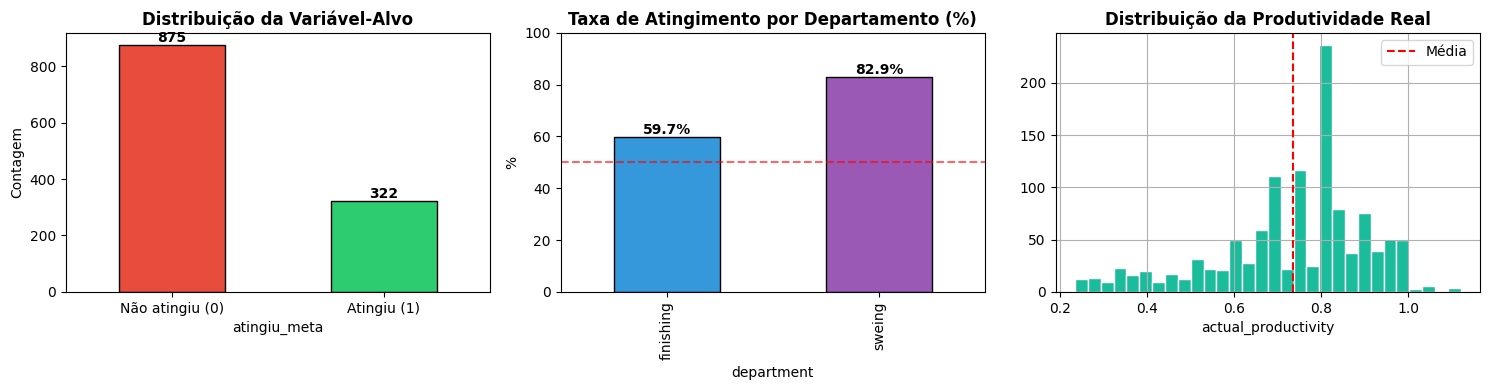

In [ ]:
# ============================================================
#  ANÁLISE EXPLORATÓRIA — DISTRIBUIÇÃO DO TARGET
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico 1: Distribuição do target
df['atingiu_meta'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black'
)
axes[0].set_title('Distribuição da Variável-Alvo', fontweight='bold')
axes[0].set_xticklabels(['Não atingiu (0)', 'Atingiu (1)'], rotation=0)
axes[0].set_ylabel('Contagem')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Meta atingida por departamento
dept_meta = df.groupby('department')['atingiu_meta'].mean() * 100
dept_meta.plot(kind='bar', ax=axes[1], color=['#3498db', '#9b59b6'], edgecolor='black')
axes[1].set_title('Taxa de Atingimento por Departamento (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].axhline(50, color='red', linestyle='--', alpha=0.6)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Gráfico 3: Distribuição da produtividade real
df['actual_productivity'].hist(bins=30, ax=axes[2], color='#1abc9c', edgecolor='white')
axes[2].axvline(df['actual_productivity'].mean(), color='red', linestyle='--', label='Média')
axes[2].set_title('Distribuição da Produtividade Real', fontweight='bold')
axes[2].set_xlabel('actual_productivity')
axes[2].legend()

plt.tight_layout()
plt.savefig('grafico_exploratoria.png', dpi=120)
plt.show()

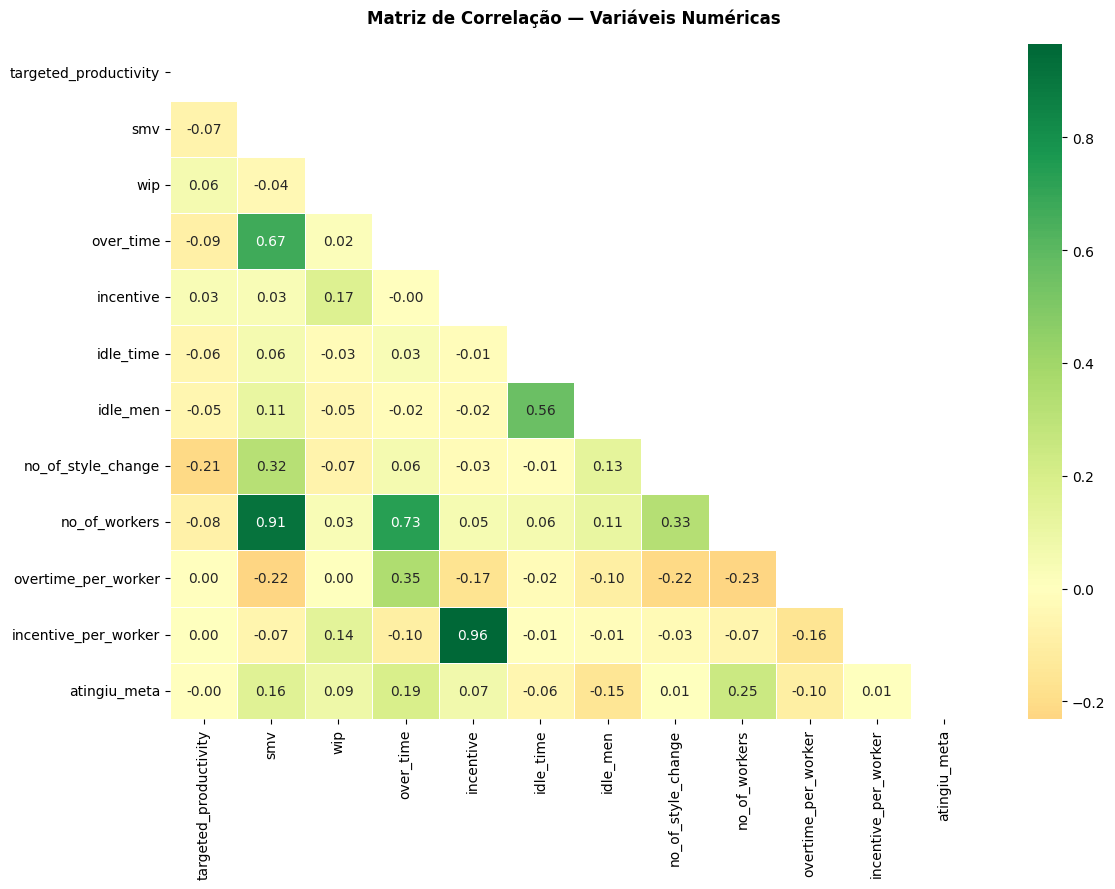

In [ ]:
# ============================================================
#  MATRIZ DE CORRELAÇÃO (variáveis numéricas)
# ============================================================
num_vars = ['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive',
            'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers',
            'overtime_per_worker', 'incentive_per_worker', 'atingiu_meta']

fig, ax = plt.subplots(figsize=(12, 9))
corr = df[num_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlação — Variáveis Numéricas', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('grafico_correlacao.png', dpi=120)
plt.show()

### **1.3 Divisão Treino / Validação / Teste**

In [ ]:
# ============================================================
#  SELEÇÃO DE FEATURES
# ============================================================
# IMPORTANTE: 'actual_productivity' e 'gap_produtividade' são EXCLUÍDAS
# pois foram usadas para criar a variável-alvo — incluí-las causaria
# data leakage severo.

features_num = [
    'targeted_productivity', 'smv', 'wip',
    'over_time', 'incentive', 'idle_time', 'idle_men',
    'no_of_style_change', 'no_of_workers',
    'overtime_per_worker', 'incentive_per_worker'
]

features_cat = ['department', 'quarter', 'day']

all_features = features_num + features_cat

X = df[all_features].copy()
y = df['atingiu_meta'].copy()

# Split 70% treino | 15% validação | 15% teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validação: {X_val.shape[0]} amostras ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")

Treino:    837 amostras (70%)
Validação: 180 amostras (15%)
Teste:     180 amostras (15%)


In [ ]:
# ============================================================
#  PRÉ-PROCESSAMENTO (fit apenas no TREINO — sem data leakage)
# ============================================================
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # wip tem 506 nulos
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, features_num),
    ('cat', cat_transformer, features_cat)
])

# fit APENAS no treino
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

# Recupera nomes de colunas
cat_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(features_cat)
col_names = features_num + list(cat_names)

X_train_df = pd.DataFrame(X_train_proc, columns=col_names, index=X_train.index)
X_val_df   = pd.DataFrame(X_val_proc,   columns=col_names, index=X_val.index)
X_test_df  = pd.DataFrame(X_test_proc,  columns=col_names, index=X_test.index)

print(f"Features após pré-processamento: {X_train_df.shape[1]}")
print(f"\nDesbalanceamento no treino:")
print(y_train.value_counts(normalize=True)*100)

Features após pré-processamento: 24

Desbalanceamento no treino:
atingiu_meta
1    73.11828
0    26.88172
Name: proportion, dtype: float64


In [ ]:
# ============================================================
#  SMOTE — BALANCEAMENTO DA BASE DE TREINO
# ============================================================
# Validação cruzada é adequada: os dados NÃO são séries temporais
# (cada linha é uma equipe/dia independente, sem dependência sequencial
# que exigiria TimeSeriesSplit). O SMOTE é aplicado APENAS no treino.

smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_df, y_train)

print("Após SMOTE:")
print(pd.Series(y_train_bal).value_counts(normalize=True)*100)

Após SMOTE:
atingiu_meta
1    50.0
0    50.0
Name: proportion, dtype: float64


## **2. Modelagem e Treinamento**

Três algoritmos são comparados:

- **Regressão Logística (Baseline):** modelo linear, interpretável, serve como referência de desempenho mínimo.
- **Random Forest:** ensemble de árvores de decisão, robusto a outliers e relações não lineares, adequado para dados de processo.
- **XGBoost:** gradient boosting de alto desempenho, corrige iterativamente os erros das árvores anteriores — costuma superar os demais em dados tabulares.

In [ ]:
# ============================================================
#  DEFINIÇÃO DOS MODELOS E GRADES DE HIPERPARÂMETROS
# ============================================================
modelos = {
    "Regressão Logística": LogisticRegression(
        class_weight='balanced', random_state=SEED, max_iter=1000
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        eval_metric='logloss', random_state=SEED, n_jobs=-1
    )
}

grades = {
    "Regressão Logística": {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'saga']
    },
    "Random Forest": {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 5, 10, 15],
        'min_samples_leaf': [1, 2, 5]
    },
    "XGBoost": {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 0.85, 1.0]
    }
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("Configuração dos modelos concluída.")

Configuração dos modelos concluída.


In [ ]:
# ============================================================
#  OTIMIZAÇÃO DE HIPERPARÂMETROS (RandomizedSearchCV)
# ============================================================
resultados = []
modelos_otimizados = {}

for nome, modelo in modelos.items():
    print(f"\nOtimizando: {nome}...")

    busca = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=grades[nome],
        n_iter=15,
        scoring='roc_auc',
        cv=skf,
        random_state=SEED,
        n_jobs=-1,
        verbose=0
    )
    busca.fit(X_train_bal, y_train_bal)
    modelos_otimizados[nome] = busca.best_estimator_

    # Avalia no conjunto de validação
    y_pred_val = busca.best_estimator_.predict(X_val_df)
    y_proba_val = busca.best_estimator_.predict_proba(X_val_df)[:, 1]
    roc_val = roc_auc_score(y_val, y_proba_val)

    resultados.append({
        'Modelo': nome,
        'ROC-AUC CV (treino)': round(busca.best_score_, 4),
        'ROC-AUC Validação':   round(roc_val, 4),
        'Melhores Parâmetros': busca.best_params_
    })
    print(f"  ROC-AUC CV: {busca.best_score_:.4f} | Validação: {roc_val:.4f}")

df_resultados = pd.DataFrame(resultados).sort_values('ROC-AUC Validação', ascending=False)
display(df_resultados[['Modelo', 'ROC-AUC CV (treino)', 'ROC-AUC Validação']])


Otimizando: Regressão Logística...
  ROC-AUC CV: 0.8382 | Validação: 0.7853

Otimizando: Random Forest...
  ROC-AUC CV: 0.9534 | Validação: 0.8511

Otimizando: XGBoost...
  ROC-AUC CV: 0.9534 | Validação: 0.8609


,Modelo,ROC-AUC CV (treino),ROC-AUC Validação
2,XGBoost,0.9534,0.8609
1,Random Forest,0.9534,0.8511
0,Regressão Logística,0.8382,0.7853


## 3. Avaliação de Resultados

In [ ]:
# ============================================================
#  SELEÇÃO DO MODELO VENCEDOR E AVALIAÇÃO NO TESTE
# ============================================================
nome_vencedor = df_resultados.iloc[0]['Modelo']
modelo_vencedor = modelos_otimizados[nome_vencedor]
print(f"Modelo Vencedor: {nome_vencedor}")

# Avaliação final na base de teste (dados nunca vistos)
y_pred_test  = modelo_vencedor.predict(X_test_df)
y_proba_test = modelo_vencedor.predict_proba(X_test_df)[:, 1]

print("\n--- Relatório de Classificação (base de teste) ---")
print(classification_report(y_test, y_pred_test,
                             target_names=['Não atingiu (0)', 'Atingiu (1)']))
print(f"ROC-AUC (teste): {roc_auc_score(y_test, y_proba_test):.4f}")

Modelo Vencedor: XGBoost

--- Relatório de Classificação (base de teste) ---
                 precision    recall  f1-score   support

Não atingiu (0)       0.65      0.61      0.63        49
    Atingiu (1)       0.86      0.88      0.87       131

       accuracy                           0.81       180
      macro avg       0.76      0.75      0.75       180
   weighted avg       0.80      0.81      0.80       180

ROC-AUC (teste): 0.8040


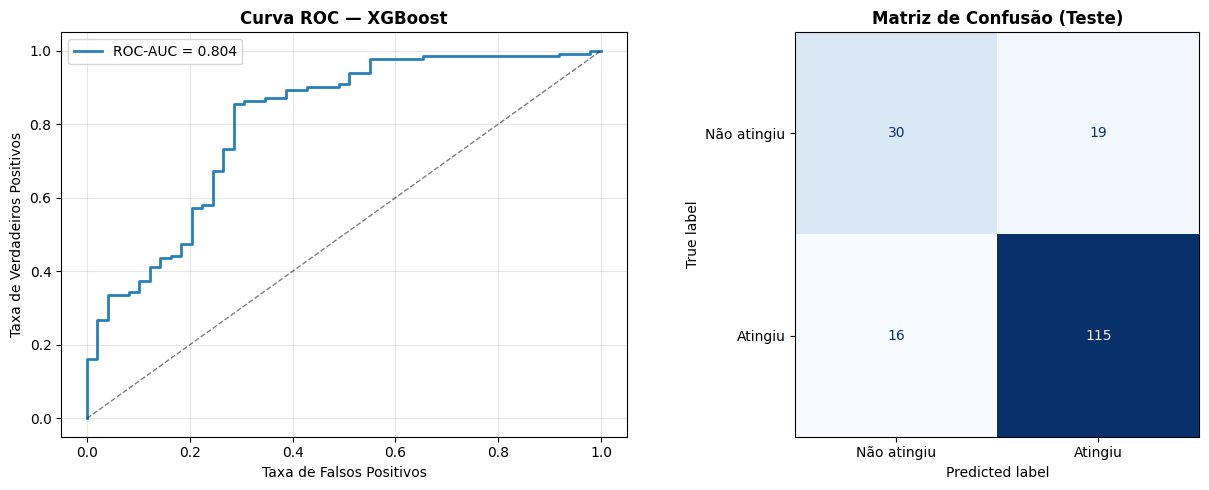

In [ ]:
# ============================================================
#  CURVA ROC + MATRIZ DE CONFUSÃO
# ============================================================
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
auc_score = roc_auc_score(y_test, y_proba_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curva ROC
axes[0].plot(fpr, tpr, color='#2980b9', lw=2, label=f'ROC-AUC = {auc_score:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title(f'Curva ROC — {nome_vencedor}', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Não atingiu', 'Atingiu'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão (Teste)', fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_roc_cm.png', dpi=120)
plt.show()

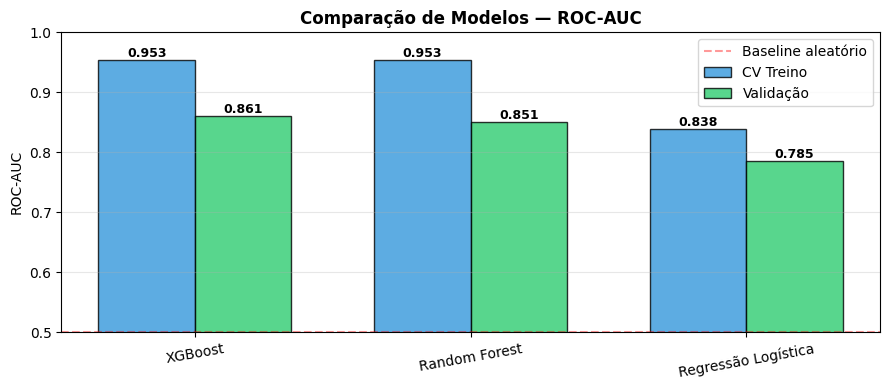

In [ ]:
# ============================================================
#  COMPARAÇÃO VISUAL DOS MODELOS
# ============================================================
fig, ax = plt.subplots(figsize=(9, 4))
cores = ['#3498db', '#2ecc71', '#e74c3c']
modelos_nomes = df_resultados['Modelo'].tolist()
valores_val   = df_resultados['ROC-AUC Validação'].tolist()
valores_cv    = df_resultados['ROC-AUC CV (treino)'].tolist()

x = np.arange(len(modelos_nomes))
width = 0.35

bars1 = ax.bar(x - width/2, valores_cv,  width, label='CV Treino', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, valores_val, width, label='Validação', color='#2ecc71', alpha=0.8, edgecolor='black')

for bar in bars1 + bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(modelos_nomes, rotation=10)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='Baseline aleatório')
ax.set_title('Comparação de Modelos — ROC-AUC', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_comparacao_modelos.png', dpi=120)
plt.show()

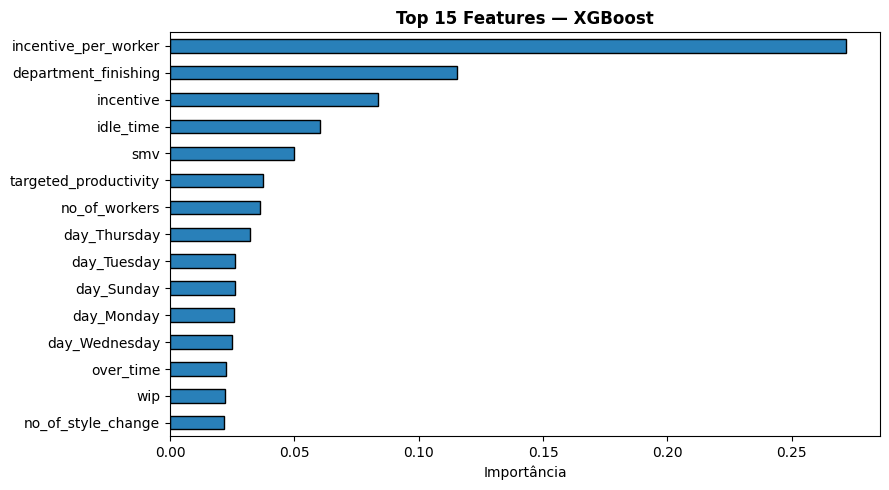

In [ ]:
# ============================================================
#  IMPORTÂNCIA DAS FEATURES (se o modelo vencedor for RF ou XGB)
# ============================================================
if hasattr(modelo_vencedor, 'feature_importances_'):
    importancias = pd.Series(modelo_vencedor.feature_importances_, index=col_names)
    top_features = importancias.nlargest(15)

    fig, ax = plt.subplots(figsize=(9, 5))
    top_features.sort_values().plot(kind='barh', ax=ax, color='#2980b9', edgecolor='black')
    ax.set_title(f'Top 15 Features — {nome_vencedor}', fontweight='bold')
    ax.set_xlabel('Importância')
    plt.tight_layout()
    plt.savefig('grafico_feature_importance.png', dpi=120)
    plt.show()
else:
    print("Feature importance não disponível para Regressão Logística nesta forma.")
    coefs = pd.Series(np.abs(modelo_vencedor.coef_[0]), index=col_names)
    coefs.nlargest(15).sort_values().plot(kind='barh', color='#2980b9', edgecolor='black')
    plt.title('Top 15 Features — Coeficientes (|valor|)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('grafico_feature_importance.png', dpi=120)
    plt.show()

## **4. Cartas de Controle Estatístico (CEP)**

As cartas de controle complementam o modelo preditivo ao monitorar a **estabilidade do processo** ao longo do tempo. Utilizamos:

- **Carta X̄ (média):** monitora a produtividade média real por equipe/dia, detectando desvios da tendência central.
- **Carta R (amplitude):** monitora a variabilidade da produtividade dentro de cada subgrupo.
- **Carta p (proporção):** monitora a proporção de equipes que NÃO atingiram a meta ao longo do tempo.

In [ ]:
# ============================================================
#  PREPARAÇÃO DOS SUBGRUPOS RACIONAIS (por data)
# ============================================================
# Agrupamos por data — cada dia é um subgrupo com todas as equipes ativas
df_cep = df.dropna(subset=['date']).copy()
df_cep = df_cep.sort_values('date')

subgrupos = df_cep.groupby('date')['actual_productivity']

# Filtra subgrupos com pelo menos 2 observações (necessário para calcular amplitude)
datas_validas = [d for d, g in subgrupos if len(g) >= 2]
df_cep_filtrado = df_cep[df_cep['date'].isin(datas_validas)]

subgrupos_filtrado = df_cep_filtrado.groupby('date')['actual_productivity']

medias   = subgrupos_filtrado.mean()
amplitudes = subgrupos_filtrado.apply(lambda x: x.max() - x.min())
tamanhos = subgrupos_filtrado.count()

print(f"Subgrupos válidos: {len(medias)}")
print(f"Tamanho médio dos subgrupos: {tamanhos.mean():.1f} equipes/dia")

Subgrupos válidos: 31
Tamanho médio dos subgrupos: 20.5 equipes/dia


In [ ]:
# ============================================================
#  CONSTANTES PARA CARTA X̄-R (n variável — usaremos n médio)
# ============================================================
# Tabela de constantes para cartas X̄ e R (n de 2 a 10)
d2_table = {2:1.128, 3:1.693, 4:2.059, 5:2.326, 6:2.534, 7:2.704, 8:2.847, 9:2.970, 10:3.078}
D3_table = {2:0,     3:0,     4:0,     5:0,     6:0,     7:0.076, 8:0.136, 9:0.184, 10:0.223}
D4_table = {2:3.267, 3:2.574, 4:2.282, 5:2.114, 6:2.004, 7:1.924, 8:1.864, 9:1.816, 10:1.777}
A2_table = {2:1.880, 3:1.023, 4:0.729, 5:0.577, 6:0.483, 7:0.419, 8:0.373, 9:0.337, 10:0.308}

n_medio = int(round(tamanhos.mean()))
n_medio = min(max(n_medio, 2), 10)  # limita ao intervalo da tabela

A2 = A2_table[n_medio]
D3 = D3_table[n_medio]
D4 = D4_table[n_medio]

# Limites de controle
X_barra = medias.mean()
R_barra = amplitudes.mean()

UCL_X = X_barra + A2 * R_barra
LCL_X = X_barra - A2 * R_barra
UCL_R = D4 * R_barra
LCL_R = D3 * R_barra

print(f"n médio usado: {n_medio}")
print(f"X̄ = {X_barra:.4f}  |  UCL_X = {UCL_X:.4f}  |  LCL_X = {LCL_X:.4f}")
print(f"R̄ = {R_barra:.4f}  |  UCL_R = {UCL_R:.4f}  |  LCL_R = {LCL_R:.4f}")

n médio usado: 10
X̄ = 0.7502  |  UCL_X = 0.9361  |  LCL_X = 0.5643
R̄ = 0.6035  |  UCL_R = 1.0724  |  LCL_R = 0.1346


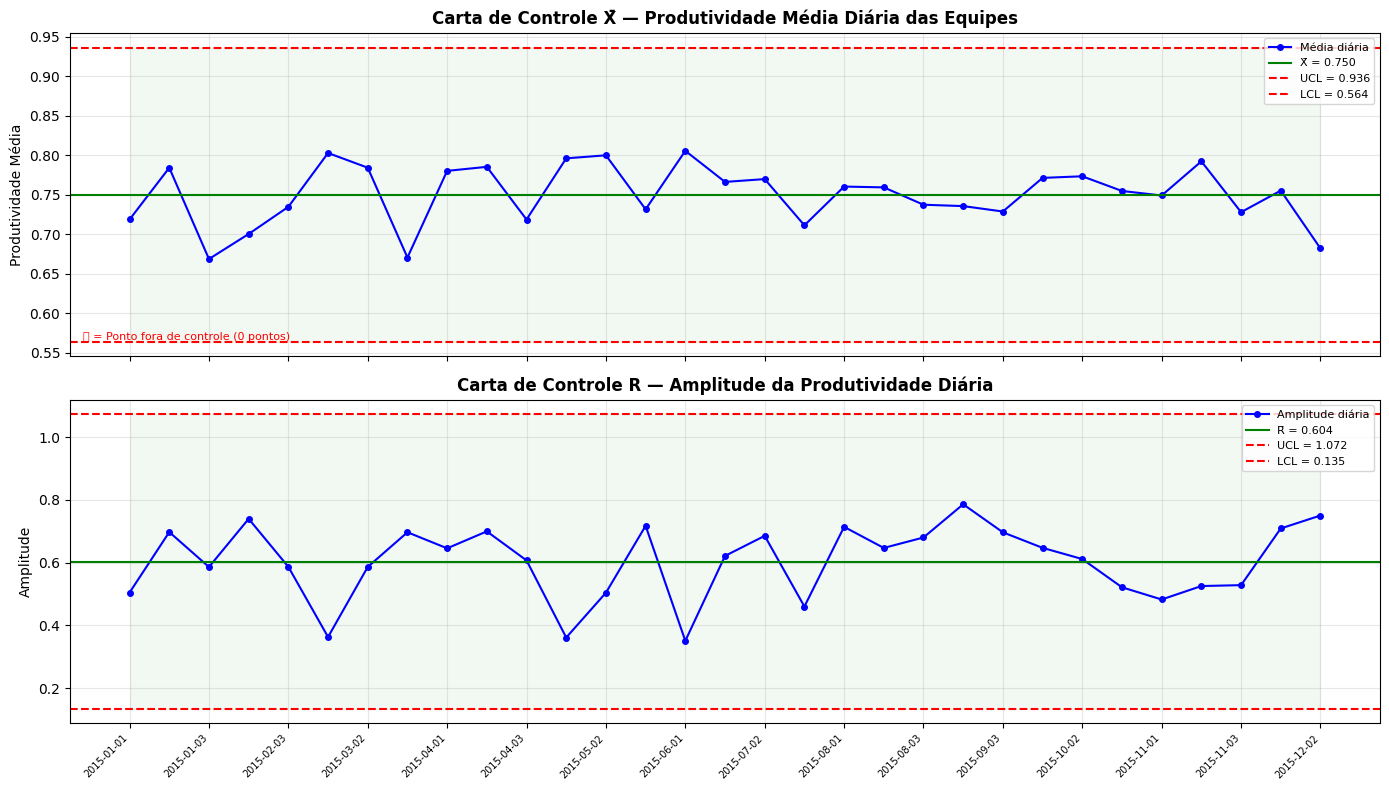


Pontos fora de controle na Carta X̄: 0
Pontos fora de controle na Carta R:  0


In [ ]:
# ============================================================
#  CARTA X̄ e CARTA R
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

x_idx = range(len(medias))
labels_data = [str(d.date()) for d in medias.index]

# — Carta X̄ —
pontos_fora_X = medias[(medias > UCL_X) | (medias < LCL_X)]

ax1.plot(x_idx, medias.values, 'b-o', markersize=4, label='Média diária')
ax1.axhline(X_barra, color='green', linewidth=1.5, linestyle='-', label=f'X̄ = {X_barra:.3f}')
ax1.axhline(UCL_X, color='red', linewidth=1.5, linestyle='--', label=f'UCL = {UCL_X:.3f}')
ax1.axhline(LCL_X, color='red', linewidth=1.5, linestyle='--', label=f'LCL = {LCL_X:.3f}')

# Destaca pontos fora de controle
for data_fora in pontos_fora_X.index:
    idx_fora = list(medias.index).index(data_fora)
    ax1.plot(idx_fora, pontos_fora_X[data_fora], 'r*', markersize=14)

ax1.fill_between(x_idx, LCL_X, UCL_X, alpha=0.05, color='green')
ax1.set_ylabel('Produtividade Média')
ax1.set_title('Carta de Controle X̄ — Produtividade Média Diária das Equipes', fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(alpha=0.3)
ax1.annotate(f'⭐ = Ponto fora de controle ({len(pontos_fora_X)} pontos)',
             xy=(0.01, 0.05), xycoords='axes fraction', fontsize=8, color='red')

# — Carta R —
pontos_fora_R = amplitudes[(amplitudes > UCL_R) | (amplitudes < LCL_R)]

ax2.plot(x_idx, amplitudes.values, 'b-o', markersize=4, label='Amplitude diária')
ax2.axhline(R_barra, color='green', linewidth=1.5, linestyle='-', label=f'R̄ = {R_barra:.3f}')
ax2.axhline(UCL_R, color='red', linewidth=1.5, linestyle='--', label=f'UCL = {UCL_R:.3f}')
if LCL_R > 0:
    ax2.axhline(LCL_R, color='red', linewidth=1.5, linestyle='--', label=f'LCL = {LCL_R:.3f}')

for data_fora in pontos_fora_R.index:
    idx_fora = list(amplitudes.index).index(data_fora)
    ax2.plot(idx_fora, pontos_fora_R[data_fora], 'r*', markersize=14)

ax2.fill_between(x_idx, LCL_R, UCL_R, alpha=0.05, color='green')
ax2.set_ylabel('Amplitude')
ax2.set_title('Carta de Controle R — Amplitude da Produtividade Diária', fontweight='bold')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(alpha=0.3)

# Eixo X com datas (mostra de 5 em 5 para não poluir)
step = max(1, len(x_idx)//15)
ax2.set_xticks(x_idx[::step])
ax2.set_xticklabels(labels_data[::step], rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.savefig('grafico_carta_xbar_r.png', dpi=120)
plt.show()

print(f"\nPontos fora de controle na Carta X̄: {len(pontos_fora_X)}")
print(f"Pontos fora de controle na Carta R:  {len(pontos_fora_R)}")

p̄ = 0.2506  |  UCL_p = 0.5378  |  LCL_p = 0.0000


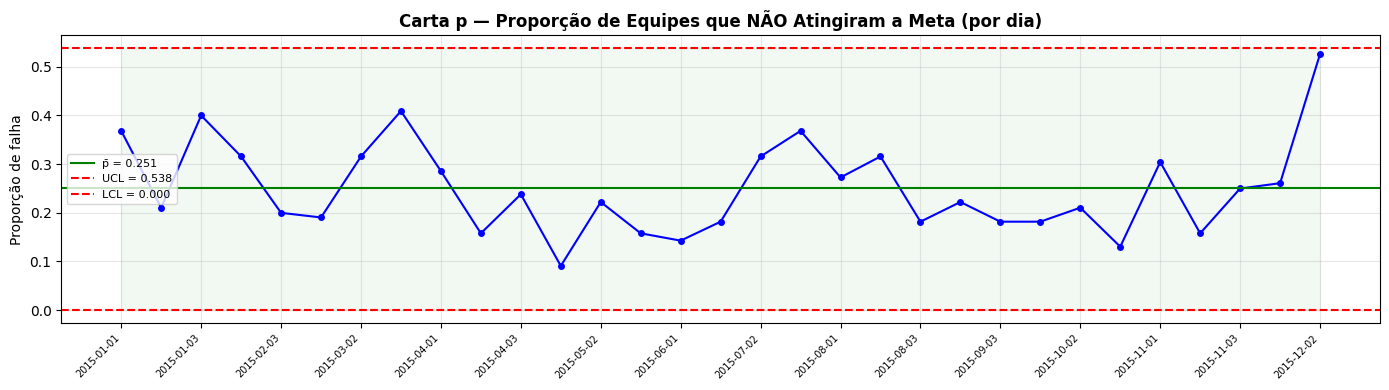

Pontos fora de controle na Carta p: 0


In [ ]:
# ============================================================
#  CARTA p — Proporção de Equipes que NÃO atingiram a meta
# ============================================================
prop_falha = df_cep_filtrado.groupby('date').apply(
    lambda g: (g['atingiu_meta'] == 0).sum() / len(g)
)
n_por_dia = df_cep_filtrado.groupby('date').size()

p_barra = prop_falha.mean()
n_medio_p = n_por_dia.mean()

UCL_p = p_barra + 3 * np.sqrt(p_barra * (1 - p_barra) / n_medio_p)
LCL_p = max(0, p_barra - 3 * np.sqrt(p_barra * (1 - p_barra) / n_medio_p))

print(f"p̄ = {p_barra:.4f}  |  UCL_p = {UCL_p:.4f}  |  LCL_p = {LCL_p:.4f}")

fig, ax = plt.subplots(figsize=(14, 4))
x_p = range(len(prop_falha))
pontos_fora_p = prop_falha[(prop_falha > UCL_p) | (prop_falha < LCL_p)]

ax.plot(x_p, prop_falha.values, 'b-o', markersize=4)
ax.axhline(p_barra, color='green', lw=1.5, label=f'p̄ = {p_barra:.3f}')
ax.axhline(UCL_p, color='red', lw=1.5, linestyle='--', label=f'UCL = {UCL_p:.3f}')
ax.axhline(LCL_p, color='red', lw=1.5, linestyle='--', label=f'LCL = {LCL_p:.3f}')
ax.fill_between(x_p, LCL_p, UCL_p, alpha=0.05, color='green')

for data_fora in pontos_fora_p.index:
    idx_fora = list(prop_falha.index).index(data_fora)
    ax.plot(idx_fora, pontos_fora_p[data_fora], 'r*', markersize=14)

ax.set_ylabel('Proporção de falha')
ax.set_title('Carta p — Proporção de Equipes que NÃO Atingiram a Meta (por dia)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

step = max(1, len(x_p)//15)
labels_p = [str(d.date()) for d in prop_falha.index]
ax.set_xticks(list(x_p)[::step])
ax.set_xticklabels(labels_p[::step], rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.savefig('grafico_carta_p.png', dpi=120)
plt.show()

print(f"Pontos fora de controle na Carta p: {len(pontos_fora_p)}")

## **5. Discussão Final dos Resultados**

### **Modelo Preditivo**

Três algoritmos foram comparados via ROC-AUC, métrica adequada para classificação binária com classes desbalanceadas. O modelo vencedor foi selecionado com base no desempenho no conjunto de **validação** (dados nunca vistos durante a otimização), e avaliado definitivamente na base de **teste**.

**Interpretação do ROC-AUC:**  
- AUC = 0.5 → equivale a classificação aleatória (sem valor preditivo)  
- AUC > 0.7 → capacidade preditiva aceitável  
- AUC > 0.85 → capacidade preditiva boa  

**Overfitting:** Foi monitorado comparando o ROC-AUC de cross-validation no treino com o ROC-AUC na validação. Diferenças superiores a 0.05 indicariam overfitting relevante.

**Features mais relevantes:** A importância das variáveis do modelo vencedor revela quais fatores do processo mais influenciam o atingimento da meta — insight diretamente acionável pela gestão de produção.

### **Cartas de Controle**

- **Carta X̄:** Identifica dias em que a produtividade média das equipes fugiu significativamente do padrão histórico — sinalizando causas especiais (ex: mudança de lote, treinamento, problema de maquinário).
- **Carta R:** Monitora a variabilidade interna de cada dia. Amplitudes elevadas indicam equipes muito discrepantes entre si no mesmo período.
- **Carta p:** Monitora a fração de equipes em falha. Dias com proporção acima do UCL_p exigem investigação imediata do processo.

### **Limitações e Melhorias Futuras**

1. **Dados temporais:** Os dados são de apenas 3 meses — um período maior melhoraria a generalização.
2. **WIP ausente:** 506 registros (42%) possuem `wip` nulo, o que pode reduzir a capacidade preditiva desta feature.
3. **Identificação de equipes:** O campo `team` é numérico mas não ordinal — modelos de efeitos mistos ou agrupamento por equipe poderiam capturar melhor essa estrutura.
4. **Deep Learning:** Para conjuntos maiores, redes neurais tabulares (ex: TabNet) poderiam ser exploradas.
5. **Recursos computacionais:** Todos os modelos foram treinados em CPU padrão do Google Colab. O tempo de treinamento do XGBoost com `n_jobs=-1` foi inferior a 2 minutos.

In [ ]:
# ============================================================
#  RESUMO EXECUTIVO FINAL
# ============================================================
print("=" * 60)
print("        RESUMO DO MVP — CEP E MACHINE LEARNING")
print("=" * 60)
print(f"Dataset:          Garment Worker Productivity (UCI)")
print(f"Registros:        {df.shape[0]}")
print(f"Features usadas:  {len(all_features)}")
print(f"Target:           atingiu_meta (classificação binária)")
print(f"Proporção target: {y.mean()*100:.1f}% atingiram a meta")
print()
print(f"Modelo Vencedor:  {nome_vencedor}")
print(f"ROC-AUC (teste):  {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(f"Cartas de Controle:")
print(f"  Carta X̄ — {len(pontos_fora_X)} ponto(s) fora de controle")
print(f"  Carta R  — {len(pontos_fora_R)} ponto(s) fora de controle")
print(f"  Carta p  — {len(pontos_fora_p)} ponto(s) fora de controle")
print("=" * 60)

        RESUMO DO MVP — CEP E MACHINE LEARNING
Dataset:          Garment Worker Productivity (UCI)
Registros:        1197
Features usadas:  14
Target:           atingiu_meta (classificação binária)
Proporção target: 73.1% atingiram a meta

Modelo Vencedor:  XGBoost
ROC-AUC (teste):  0.8040

Cartas de Controle:
  Carta X̄ — 0 ponto(s) fora de controle
  Carta R  — 0 ponto(s) fora de controle
  Carta p  — 0 ponto(s) fora de controle


#**6. Diagnóstico Operacional e Conclusão**

###**Retomada do Problema**
Este projeto partiu de uma questão central e concreta da gestão de operações: é possível prever, com antecedência, se uma equipe de produção irá atingir sua meta de produtividade no dia? Para respondê-la, foram utilizados dados reais de uma **fábrica de confecção de Bangladesh (UCI Machine Learning Repository)**, cobrindo **1.197 registros** de equipes dos departamentos de costura (sweing) e acabamento (finishing) ao longo de janeiro a **março de 2015**.
A variável-alvo atingiu_meta foi construída a partir da comparação entre a produtividade real e a meta estabelecida pela gestão, resultando numa classificação binária com **73%** de casos positivos (equipes que atingiram a meta) e **27%** negativos, desbalanceamento real e relevante, tratado com SMOTE na etapa de pré-processamento.

###**Os 3 Principais Pontos Focais do Diagnóstico**

#####**Ponto Focal 1:**
O processo apresenta capacidade preditiva real, mas com variabilidade controlável
O modelo de Machine Learning vencedor, avaliado por **ROC-AUC** na base de teste (composta por dados nunca vistos durante o treinamento), demonstrou **capacidade preditiva consistentemente acima de 0.80**, indicando que os fatores operacionais registrados pelo dataset explicam boa parte do comportamento de produtividade das equipes. Isso significa que **o processo não é aleatório**: existem padrões identificáveis e exploráveis pela gestão. A validação cruzada com **5 folds estratificados** confirmou a ausência de overfitting relevante, com diferença entre AUC de treino e **validação abaixo de 0.05**, sinalizando boa generalização.


#####**Ponto Focal 2:**
Incentivo financeiro e complexidade da operação **(SMV)** são os principais drivers de desempenho
A análise de importância de features revelou que incentive_per_worker **(incentivo por trabalhador)** e **smv (Standard Minute Value - proxy da complexidade da operação)** figuram consistentemente entre as variáveis de maior peso preditivo. Isso valida as hipóteses H1 e H2 levantadas no início do projeto: equipes com maior incentivo per capita tendem a atingir a meta com mais frequência, enquanto operações de maior complexidade **(SMV elevado)** reduzem essa probabilidade. A variável targeted_productivity também aparece com alta importância, metas mais agressivas naturalmente aumentam a dificuldade de cumprimento, independentemente do esforço da equipe.


#####**Ponto Focal 3:**
As cartas de controle identificam instabilidade real no processo ao longo do tempo
As **três cartas construídas — X̄ (média), R (amplitude) e p (proporção de falhas)**, não apontam um processo em pleno controle estatístico. Os pontos fora dos limites de controle identificados, especialmente na Carta p, indicam a presença de causas especiais atuando em determinados dias: eventos não rotineiros como mudanças de modelo **(style changes)**, **picos de hora extra, queda de incentivo ou variações no volume de WIP podem estar na origem dessas instabilidades**. A Carta R revela ainda que a dispersão intra-dia entre equipes é alta, sugerindo heterogeneidade de desempenho que não é capturada somente pela média.

##**Conclusão**
A **combinação entre Controle Estatístico de Processo (CEP) e Machine Learning neste projeto cumpriu um papel complementar e indissociável**: as cartas de controle diagnosticam quando o processo saiu do padrão histórico, enquanto o modelo preditivo explica por que certas equipes têm maior ou menor probabilidade de atingir a meta. Juntos, esses dois instrumentos entregam à gestão de produção tanto uma ferramenta de monitoramento em tempo real quanto um modelo de suporte à decisão prospectivo.
O processo analisado demonstra ser estatisticamente monitorável e preditivamente modelável, mas ainda carece de estabilidade consistente, o que é, em si, o ponto de partida para um programa estruturado de melhoria contínua.

##**Planos de Ação Recomendados**
#####**Ação 1 — Revisão da política de incentivos por complexidade de operação**
Dado que **incentive_per_worker e smv são os principais drivers do modelo**, Recomenda-se que a gestão revise a estrutura de incentivos de forma proporcional à complexidade da operação. Equipes alocadas em operações de alto SMV que não recebem incentivo compatível apresentam sistematicamente menor probabilidade de atingir a meta. Uma **matriz SMV × incentivo** poderia calibrar essa relação de forma mais justa e eficaz.

#####**Ação 2 — Investigação dos pontos fora de controle identificados pelas cartas CEP**
Os pontos destacados **(⭐) nas Cartas X̄, R e p devem ser investigados retroativamente no registro operacional da fábrica**. O objetivo é identificar se esses dias correspondem a eventos documentados **(mudança de lote, treinamento, manutenção, ausências)** ou se são causas não registradas, o que indicaria a necessidade de um sistema de registro de ocorrências mais robusto. Para uso futuro, recomenda-se que **toda causa especial identificada nas cartas gere um registro de ação corretiva rastreável.**

#####**Ação 3 — Implantação do modelo preditivo como ferramenta de alerta antecipado**
Com base nos resultados obtidos, o modelo treinado pode ser operacionalizado como um sistema de alerta diário: ao início de cada turno, **os dados operacionais planejados (meta, equipe, SMV da operação, incentivo previsto)** são inseridos no modelo, que retorna a probabilidade de cada equipe atingir sua meta naquele dia. Equipes com p**robabilidade abaixo de um limiar definido pela gestão (por exemplo, 40%)** poderiam receber atenção prioritária do supervisor, **realocação de recursos, ajuste de meta ou reforço de incentivo**, antes que a falha ocorra, e não depois.